## Vanishing Gradients
- Gradients get smaller and smaller during backwards pass
- Earlier layers get small parameters updates
- Model doesn't learn

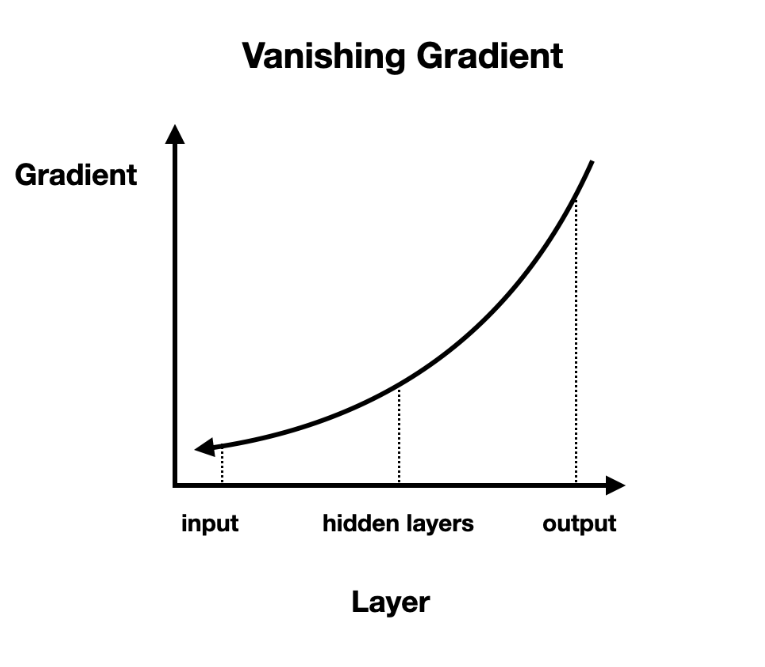

## Exploding gradients
- Gradients get bigger and bigger
- Parameter updates are too large
- Training diverges

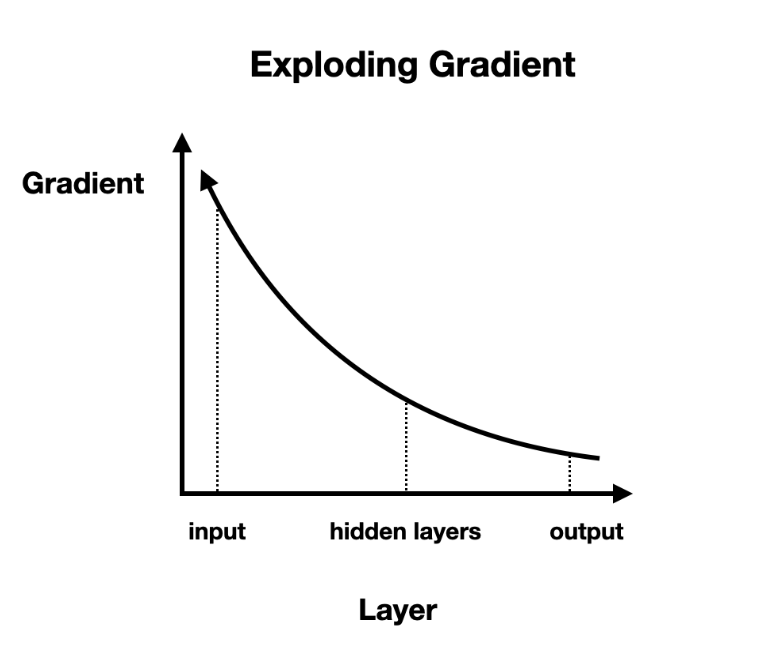

# Solution to unstable gradients
1. Proper weights initialization
2. Good activations
3. Batch normalization

Let's review this steps

#### Weights initialization
 - normal/random initialization

In [ ]:
layer = nn.Linear(8, 1)
print(layer.weight)

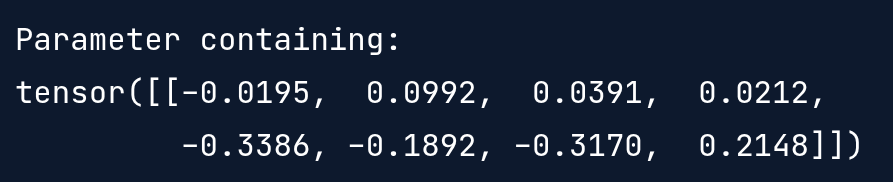

- Good initialization ensures:
    - Variance of layer inputs = variance of layer outputs
    - Variance of gradients the same before and after a layer
- How to achieve this depends on the activation:
    - For ReLu and similar, we can use He/Kaiming initialization

In [ ]:
import torch.nn.init as init

init.kaiming_uniform_(layer.weight)
print(layer.weight)

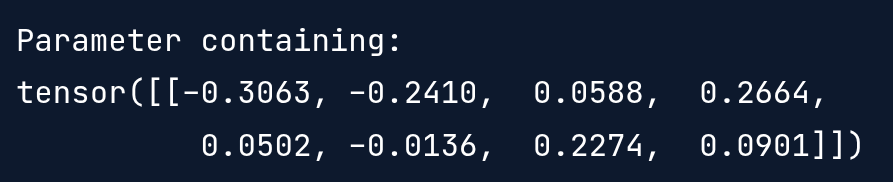

On OOP class we need to change create this init

In [ ]:
init.kaiming_uniform_(self.fc1.weight)
init.kaiming_uniform_(self.fc2.weight)
init.kaiming_uniform_(self.fc3.weight, nonlinearity='sigmoid')

It's going to look like this:


In [ ]:
from torch import nn

class Net(nn.module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)

        #Initialize weights here
        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc3.weight, nonlinearity='sigmoid')

    def forward(self, x):
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = nn.functional.sigmoid(self.fc3(x))
        return x

net = Net()

## Activation functions
#### ReLU
- Often used as the default activation
- ```nn.functional.relu()```
- Zero for negative inputs - dying neurons

#### ELU
- Built on top of ReLU
- ```nn.functional.elu()```
- Non-zero gradients for negative values, helps against dying neurons
- Average output around zero - helps against vanishing gradients

## Batch normalization
After a layer:
1. Normalize the layer's outputs by:
    - subtracting the mean
    - dividing by the standard deviation
2. Scale and shift normalized outputs using learned parameters
Model learns optimal inputs distribution for each layer:
    - Faster loss decrease
    - Helps against unstable gradients

In [ ]:
from torch import nn

class Net(nn.module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 16)
        self.bn1 = nn.BatchNorm1d(16)
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)
        self.fc3 = nn.Linear(8, 1)

        #Initialize weights here
        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc3.weight, nonlinearity='sigmoid')

    def forward(self, x):
        x = nn.functional.elu(self.bn1(self.fc1(x)))
        x = nn.functional.elu(self.bn2(self.fc2(x)))
        x = nn.functional.sigmoid(self.fc3(x))
        return x

net = Net()